# ✍️ Task 3: Handwritten Character Recognition
**CodeAlpha Machine Learning Internship**

Identify handwritten characters (A–Z) using Deep CNN on EMNIST dataset.



In [1]:
# ── Install & Import ──────────────────────────
!pip install -q tensorflow tensorflow-datasets numpy matplotlib seaborn scikit-learn

import os, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Dense,
                                      Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import mnist

print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ GPU: {tf.config.list_physical_devices('GPU')}")

✅ TensorFlow: 2.20.0
✅ GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ── Load Dataset ─────────────────────────────
BATCH_SIZE = 128
EPOCHS     = 30

try:
    import tensorflow_datasets as tfds
    print("Loading EMNIST Letters (A-Z, 26 classes)...")

    def preprocess(img, label):
        img = tf.cast(img, tf.float32) / 255.0
        return img, label - 1  # labels 1-26 → 0-25

    train_ds = (tfds.load('emnist/letters',split='train',as_supervised=True)
                .map(preprocess).batch(BATCH_SIZE).prefetch(2))
    test_ds  = (tfds.load('emnist/letters',split='test',as_supervised=True)
                .map(preprocess).batch(BATCH_SIZE).prefetch(2))

    # For sklearn metrics
    X_test_np, y_test_np = [], []
    for img,lbl in (tfds.load('emnist/letters',split='test',as_supervised=True)
                    .map(preprocess)):
        X_test_np.append(img.numpy()); y_test_np.append(lbl.numpy())
    X_test_np = np.array(X_test_np); y_test_np = np.array(y_test_np)

    n_classes  = 26
    label_map  = {i:chr(ord('A')+i) for i in range(26)}
    use_tfds   = True
    print(f"✅ EMNIST: {len(X_test_np)} test samples, 26 classes (A-Z)")

except Exception as e:
    print(f"EMNIST failed ({e}) → using MNIST digits")
    (X_train,y_train),(X_test_np,y_test_np) = mnist.load_data()
    X_train    = X_train.astype('float32')[...,np.newaxis]/255.0
    X_test_np  = X_test_np.astype('float32')[...,np.newaxis]/255.0
    n_classes  = 10
    label_map  = {i:str(i) for i in range(10)}
    use_tfds   = False
    print(f"✅ MNIST: {X_train.shape[0]} train, {X_test_np.shape[0]} test, 10 classes")

Loading EMNIST Letters (A-Z, 26 classes)...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.H6JNI2_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.H6JNI2_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
✅ EMNIST: 14800 test samples, 26 classes (A-Z)


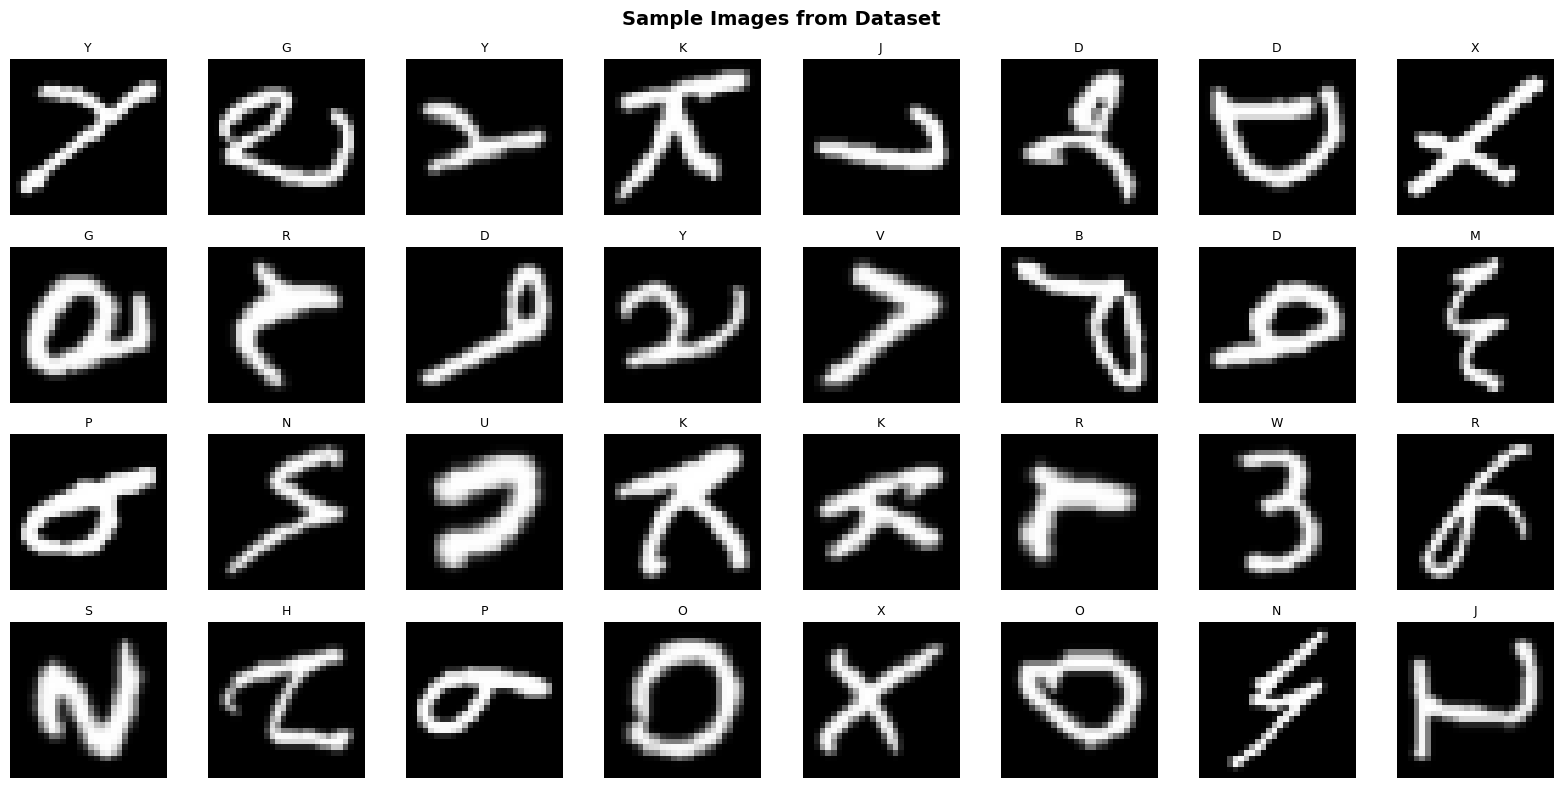

✅ Sample grid saved!


In [3]:
# ── Sample Images ────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Sample Images from Dataset', fontsize=14, fontweight='bold')

if use_tfds:
    imgs, lbls = next(iter(
        tfds.load('emnist/letters',split='train',as_supervised=True)
        .map(lambda x,y:(tf.cast(x,tf.float32)/255.0, y-1))
        .take(32).batch(32)
    ))
    imgs = imgs.numpy(); lbls = lbls.numpy()
else:
    idx = np.random.choice(len(X_train),32,replace=False)
    imgs = X_train[idx]; lbls = y_train[idx]

for i,ax in enumerate(axes.flat):
    ax.imshow(imgs[i].squeeze(),cmap='gray')
    ax.set_title(label_map[int(lbls[i])],fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('task3_samples.png',dpi=120,bbox_inches='tight')
plt.show()
print("✅ Sample grid saved!")

In [4]:
# ── Build Deep CNN ────────────────────────────
inp = Input(shape=(28,28,1))

# Block 1
x = Conv2D(32,(3,3),padding='same',activation='relu')(inp)
x = BatchNormalization()(x); x = Conv2D(32,(3,3),padding='same',activation='relu')(x)
x = BatchNormalization()(x); x = MaxPooling2D(2)(x); x = Dropout(0.25)(x)

# Block 2
x = Conv2D(64,(3,3),padding='same',activation='relu')(x)
x = BatchNormalization()(x); x = Conv2D(64,(3,3),padding='same',activation='relu')(x)
x = BatchNormalization()(x); x = MaxPooling2D(2)(x); x = Dropout(0.30)(x)

# Block 3
x = Conv2D(128,(3,3),padding='same',activation='relu')(x)
x = BatchNormalization()(x); x = Conv2D(128,(3,3),padding='same',activation='relu')(x)
x = BatchNormalization()(x); x = GlobalAveragePooling2D()(x); x = Dropout(0.40)(x)

# Classifier
x = Dense(256,activation='relu')(x)
x = BatchNormalization()(x); x = Dropout(0.40)(x)
out = Dense(n_classes,activation='softmax')(x)

model = Model(inp,out,name='CharRecognitionCNN')
model.compile(optimizer=Adam(1e-3),
              loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()
print(f"\n✅ Parameters: {model.count_params():,}")

Model: "CharRecognitionCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 328,954 (1.25 MB)

 Trainable params: 327,546 (1.25 MB)

 Non-trainable params: 1,408 (5.50 KB)


✅ Parameters: 328,954


In [5]:
# ── Train Model ───────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_accuracy',patience=8,restore_best_weights=True,verbose=1),
    ReduceLROnPlateau(factor=0.5,patience=4,min_lr=1e-6,verbose=1),
    ModelCheckpoint('task3_best_model.keras',monitor='val_accuracy',save_best_only=True)
]

if use_tfds:
    history = model.fit(train_ds, validation_data=test_ds,
                        epochs=EPOCHS, callbacks=callbacks, verbose=1)
else:
    dg = ImageDataGenerator(rotation_range=10,width_shift_range=0.1,
                             height_shift_range=0.1,zoom_range=0.1,validation_split=0.1)
    history = model.fit(
        dg.flow(X_train,y_train,batch_size=BATCH_SIZE,subset='training'),
        validation_data=dg.flow(X_train,y_train,batch_size=BATCH_SIZE,subset='validation'),
        epochs=EPOCHS, callbacks=callbacks, verbose=1)

Epoch 1/30
694/694 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.7736 - loss: 0.7369 - val_accuracy: 0.8710 - val_loss: 0.3643 - learning_rate: 0.0010
Epoch 2/30
694/694 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9013 - loss: 0.3001 - val_accuracy: 0.9169 - val_loss: 0.2336 - learning_rate: 0.0010
Epoch 3/30
694/694 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9171 - loss: 0.2494 - val_accuracy: 0.9280 - val_loss: 0.2118 - learning_rate: 0.0010
Epoch 4/30
694/694 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9238 - loss: 0.2253 - val_accuracy: 0.9324 - val_loss: 0.1987 - learning_rate: 0.0010
Epoch 5/30
694/694 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9299 - loss: 0.2075 - val_accuracy: 0.9324 - val_loss: 0.1974 - learning_rate: 0.0010
Epoch 6/30
694/694 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9326 - loss: 0.1974 - val_accuracy: 0.9291 - val_loss: 0.2054 - learning_rate: 0.0010
Epoch 7/30
694/694 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9352 - lo

✅ Test Accuracy: 0.9471 (94.71%)


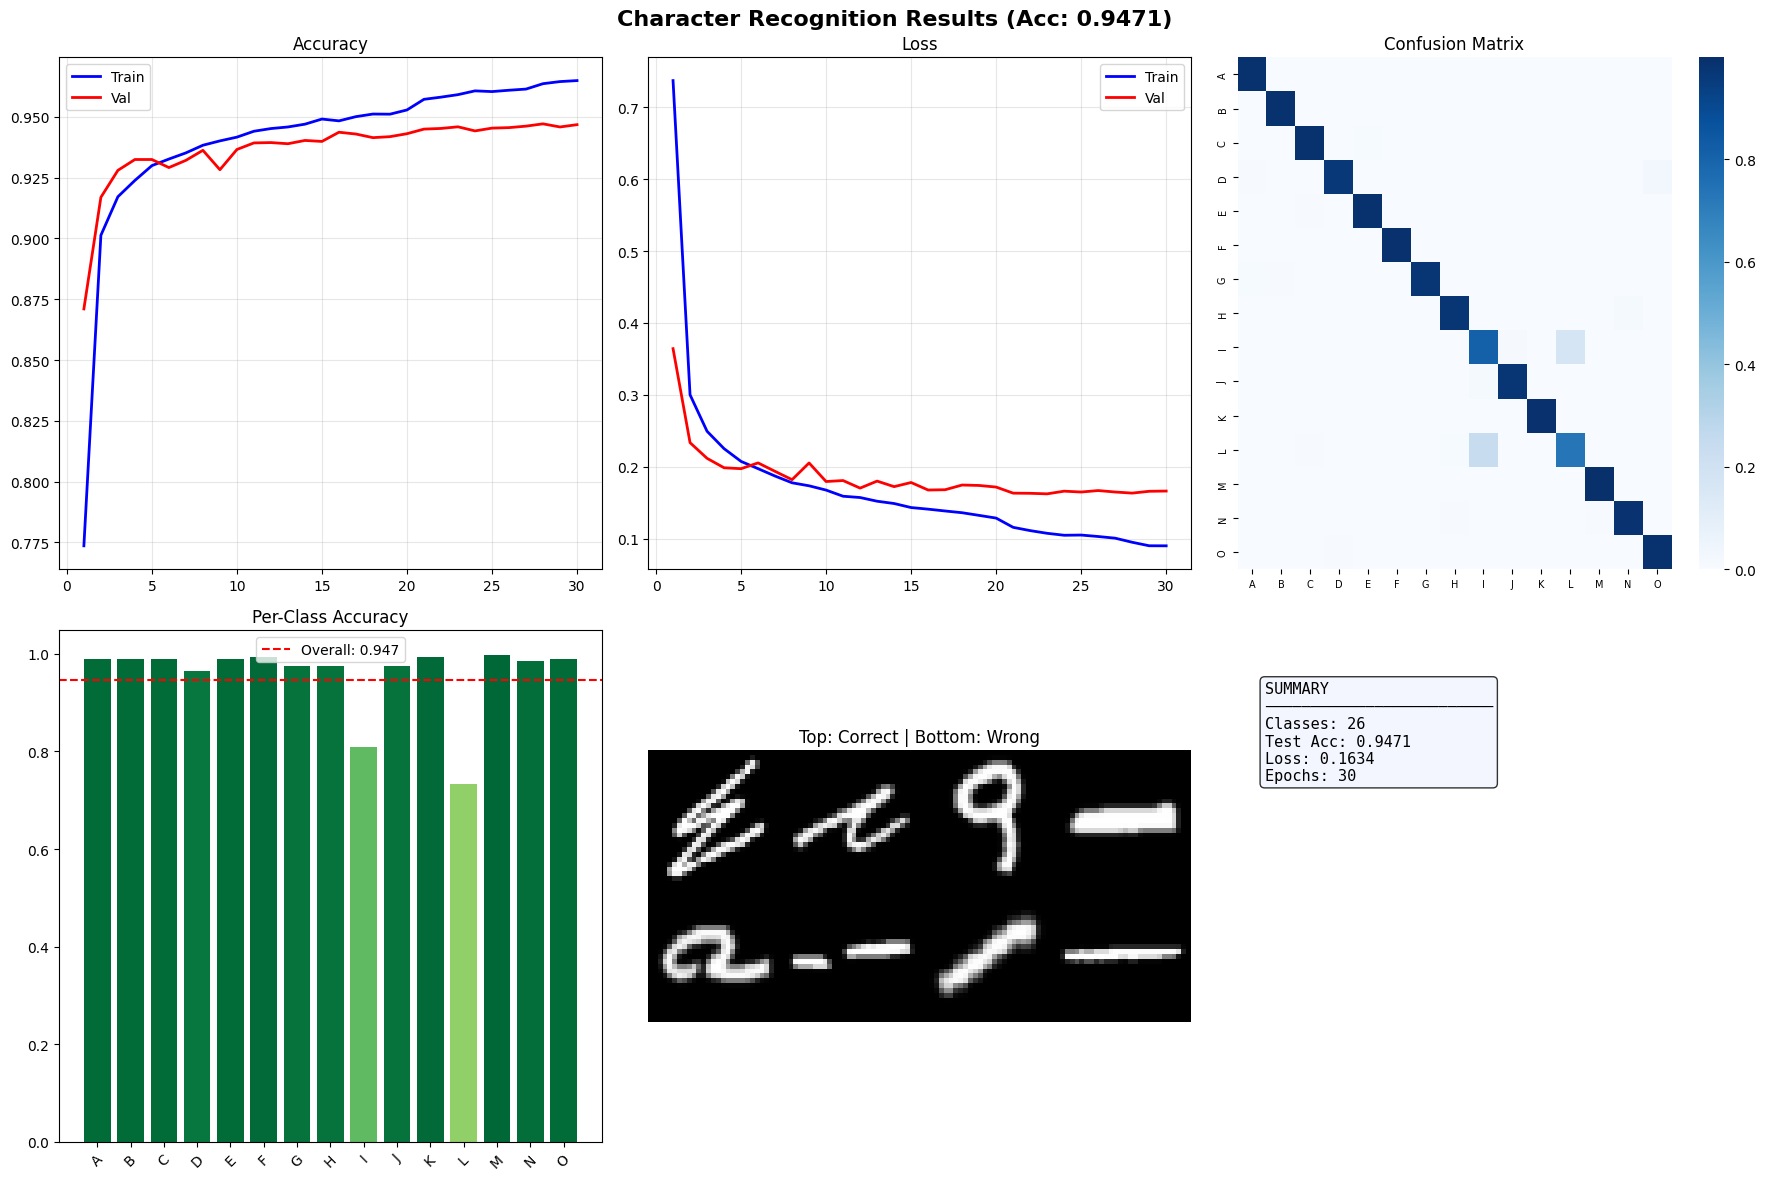

In [6]:
# ── Evaluate & Visualize ─────────────────────
if use_tfds:
    loss,acc = model.evaluate(test_ds,verbose=0)
else:
    loss,acc = model.evaluate(X_test_np,y_test_np,verbose=0)

y_pred = np.argmax(model.predict(X_test_np,verbose=0),axis=1)
y_true = y_test_np
class_labels = [label_map[i] for i in range(n_classes)]

print(f"✅ Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

fig = plt.figure(figsize=(18,12))
fig.suptitle(f'Character Recognition Results (Acc: {acc:.4f})',fontsize=16,fontweight='bold')

# Accuracy
ax1 = fig.add_subplot(2,3,1); ep = range(1,len(history.history['accuracy'])+1)
ax1.plot(ep,history.history['accuracy'],'b-',lw=2,label='Train')
ax1.plot(ep,history.history['val_accuracy'],'r-',lw=2,label='Val')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2 = fig.add_subplot(2,3,2)
ax2.plot(ep,history.history['loss'],'b-',lw=2,label='Train')
ax2.plot(ep,history.history['val_loss'],'r-',lw=2,label='Val')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

# Confusion Matrix (first 15 classes if EMNIST)
ax3 = fig.add_subplot(2,3,3)
show_cls = list(range(min(15,n_classes)))
mask = np.isin(y_true,show_cls)
cm = confusion_matrix(y_true[mask],y_pred[mask],labels=show_cls)
sns.heatmap(cm/cm.sum(axis=1,keepdims=True),annot=False,ax=ax3,cmap='Blues',
            xticklabels=[label_map[i] for i in show_cls],
            yticklabels=[label_map[i] for i in show_cls])
ax3.set_title('Confusion Matrix'); ax3.tick_params(labelsize=7)

# Per-class accuracy
ax4 = fig.add_subplot(2,3,4)
per = cm.diagonal()/cm.sum(axis=1)
ax4.bar(range(len(show_cls)),per,color=plt.cm.RdYlGn(per))
ax4.set_xticks(range(len(show_cls))); ax4.set_xticklabels([label_map[i] for i in show_cls],rotation=45)
ax4.axhline(y=acc,color='red',linestyle='--',label=f'Overall: {acc:.3f}')
ax4.set_title('Per-Class Accuracy'); ax4.legend()

# Sample predictions
ax5 = fig.add_subplot(2,3,5)
ax5.axis('off')
correct = np.where(y_pred==y_true)[0][:4]; wrong = np.where(y_pred!=y_true)[0][:4]
grid = np.zeros((2*28,4*28))
for i,idx in enumerate(correct):
    grid[:28,i*28:(i+1)*28] = X_test_np[idx].squeeze()
for i,idx in enumerate(wrong):
    grid[28:,i*28:(i+1)*28] = X_test_np[idx].squeeze()
ax5.imshow(grid,cmap='gray'); ax5.set_title('Top: Correct | Bottom: Wrong')

# Summary
ax6 = fig.add_subplot(2,3,6); ax6.axis('off')
ax6.text(0.05,0.9,
    f"SUMMARY\n{'─'*25}\nClasses: {n_classes}\nTest Acc: {acc:.4f}\nLoss: {loss:.4f}\nEpochs: {len(history.history['accuracy'])}",
    transform=ax6.transAxes,va='top',family='monospace',fontsize=11,
    bbox=dict(boxstyle='round',facecolor='#f0f4ff',alpha=0.8))

plt.tight_layout()
plt.savefig('task3_results.png',dpi=150,bbox_inches='tight')
plt.show()

if n_classes<=10:
    print(classification_report(y_true,y_pred,target_names=class_labels))

In [7]:
# ── Download Files ────────────────────────────
from google.colab import files
files.download('task3_samples.png')
files.download('task3_results.png')
files.download('task3_best_model.keras')
print("✅ Task 3 Complete!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Task 3 Complete!
